# GARCH Models for Global Equity Indices

## Objective

Estimate conditional volatility models for four major equity indices and
compare **volatility persistence** across markets:

Index: 
- **S&P 500** : United States 
- **EURO STOXX 50** : Eurozone 
- **Nikkei 225** : Japan 
- **FTSE 100** : United Kingdom 

## The model

Financial returns exhibit **volatility clustering** — large moves tend to
be followed by large moves. A constant-variance model cannot capture this.
GARCH(1,1) specifies the conditional variance as a function of both the
previous shock and the previous variance:

$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

| Parameter | Name | Interpretation |
|---|---|---|
| $\omega$ | constant | Baseline variance level |
| $\alpha$ | **ARCH term** | Reaction to yesterday's shock (news impact) |
| $\beta$ | **GARCH term** | Memory of yesterday's variance |
| $\alpha + \beta$ | **persistence** | How slowly volatility mean-reverts |

Persistence is the central quantity of this project. Values close to 1
imply shocks to volatility decay very slowly; the **half-life** of a
volatility shock is $\ln(0.5) / \ln(\alpha + \beta)$ trading days.

## Sample period

**2005-01-01 to present.** Chosen deliberately to span four distinct
volatility regimes:

- **2008** — Global Financial Crisis (credit-driven, global)
- **2011** — European Sovereign Debt Crisis (regional, asymmetric across markets)
- **2020** — COVID crash (globally synchronised, extremely fast)
- **2022** — Inflation and rate-hike shock (slow-moving, persistent)

A shorter window (e.g. 2015–2025) would contain only one major event,
making cross-market differences difficult to identify.

## Roadmap

| Stage | Content | Question answered |
|---|---|---|
| **1** | Data acquisition, log returns, summary statistics | What does the raw data look like, and is it clean? |
| **2** | Exploratory analysis, ARCH-LM and Ljung-Box tests | Is a constant-variance model rejected by the data? |
| **3** | GARCH(1,1) estimation | How large are $\alpha$, $\beta$, and persistence in each market? |
| **4** | Distributional assumptions: Normal vs Student-$t$ | Do the standardised residuals still show fat tails? |
| **5** | Asymmetric extensions: GJR-GARCH, EGARCH | Do negative shocks raise volatility more than positive ones? |
| **6** | Diagnostics and cross-market comparison | Which market's volatility is most persistent, and why? |
| **7** | VaR backtesting | Does the model produce risk numbers that survive validation? |

Each stage ends with a saved figure or results table in `outputs/`.

# Stage 1 — Data

**Goal.** Obtain clean, comparable return series for four equity indices
and establish the stylised facts that motivate volatility modelling.

**Steps.** Download prices → convert to percentage log returns →
verify data integrity → cache a snapshot for reproducibility.

**Key design decisions.**
1. No calendar alignment — each index keeps its own trading days.
2. Common start date of 2007-04-01, imposed by `^STOXX50E` availability.
3. Returns scaled by 100 for numerical stability of the MLE optimiser.

**Outcome.** Four series of ~4,800 observations each, all displaying
excess kurtosis and negative skewness — the empirical signature that
motivates Stage 2.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import(
    INDICES,
    download_index_prices,
    compute_log_returns,
    summary_statistics,
    save_returns,
)

from src.plots import (
    plot_prices,
    plot_returns,
    plot_rolling_volatility,
    plot_return_distributions,
)

from src.plots import (
    plot_prices,
    plot_returns,
    plot_rolling_volatility,
    plot_rolling_volatility_panels,     # 新增
    plot_return_distributions,
)

from src.diagnostics import arch_lm_test, ljung_box_test

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

print("Imports OK")

Imports OK


## 1.1 Data acquisition

**Design decision: no calendar alignment.**

The four markets trade on different calendars ： Japan has Golden Week, the UK has bank holidays, the US has Thanksgiving. Merging them into one DataFrame and dropping incomplete rows would discard observations *systematically*, not at random.

More importantly, GARCH models a **recursive** relationship: $\sigma_t^2$ depends on $\sigma_{t-1}^2$. Deleting arbitrary days breaks that recursion and biases the persistence estimate ： precisely the quantity this project sets out to measure.

Each index is therefore kept as an independent series with its own calendar, stored in a `dict` rather than a `DataFrame`.

In [2]:
# Download prices and compute log returns

prices = download_index_prices(start="2007-04-01")
# Downloads each ticker independently; the function prints obs count and date range.

returns = compute_log_returns(prices)
# dict[label] -> Series of percentage log returns

# Confirm we have Series, not DataFrames (i.e. that .squeeze() did its job)
print()
for label, r in returns.items():
    print(f"{label:8s} {type(r).__name__:10s} {len(r):>5,} obs")

SPX      4,889 obs   2007-04-02 -> 2026-09-04
SX5E     4,870 obs   2007-04-02 -> 2026-09-04
Nikkei   4,751 obs   2007-04-02 -> 2026-09-04
FTSE     4,906 obs   2007-04-02 -> 2026-09-04

SPX      Series     4,888 obs
SX5E     Series     4,869 obs
Nikkei   Series     4,750 obs
FTSE     Series     4,905 obs


**2007-04-01 to present**, chosen to span four distinct volatility regimes.
The start date is set by data availability for `^STOXX50E` 

### 1.2 Quantifying the cost of alignment

The previous section argued against calendar alignment on methodological
grounds. Here we measure what it would actually cost in observations,
turning a design choice into an evidenced one.

In [3]:
# How much data would calendar alignment destroy?

# pd.DataFrame(dict_of_series) performs an outer join on the date index.
# A market closed on a given day produces a NaN in its column.
df_aligned = pd.DataFrame(returns).dropna()   # keep only days when ALL four traded

print(f"{'Index':8s} {'Standalone':>12s} {'Aligned':>10s} {'Lost':>8s} {'Loss %':>8s}")
print("-" * 52)
for label, r in returns.items():
    lost = len(r) - len(df_aligned)
    print(f"{label:8s} {len(r):>12,} {len(df_aligned):>10,} {lost:>8,} {lost/len(r):>7.1%}")

Index      Standalone    Aligned     Lost   Loss %
----------------------------------------------------
SPX             4,888      4,441      447    9.1%
SX5E            4,869      4,441      428    8.8%
Nikkei          4,750      4,441      309    6.5%
FTSE            4,905      4,441      464    9.5%


**Result.** Alignment would reduce the common sample to 4,441 observations,
costing between 6.5% and 9.5% of each series.

Note the ordering: the Nikkei loses the *least* in percentage terms
despite Japan having the most public holidays. This is because alignment
takes the intersection： the Nikkei's own holidays already shorten its
standalone series, while the FTSE, which is the longest, absorbs the most
cuts from other markets' calendars.

The count is only part of the argument. The days removed are not random:
holidays cluster (Golden Week, Christmas, Easter), so alignment deletes
contiguous blocks rather than scattered days, severing the variance
recursion $\sigma_t^2 = f(\sigma_{t-1}^2, \epsilon_{t-1}^2)$ across each gap.

## 1.3 Summary statistics

Three quantities make the empirical case for GARCH *before* any model is fitted:

| Statistic | What to look for | Why it matters |
|---|---|---|
| **Excess kurtosis** | Typically 8–15 for daily equity indices | Normal implies 0. Fat tails motivate **Student-t innovations** (Stage 4). |
| **Skewness** | Usually negative | Crashes are sharper than rallies — motivates **GJR-GARCH** (Stage 5). |
| **Jarque–Bera p-value** | Essentially 0 | Formally rejects normality of unconditional returns. |

Note that fat tails alone do **not** prove volatility clustering — i.i.d. draws from a
$t$-distribution would also show excess kurtosis. The formal test for clustering
(**ARCH-LM**) comes in the next section.

In [4]:
# Cell 3 — Summary statistics
stats_table = summary_statistics(returns)
stats_table

,N,Start,End,Mean,Std,Ann. Vol (%),Skew,Excess Kurt,Min,Max,JB p-value
Index,,,,,,,,,,,
SPX,4888,2007-04-03,2026-09-04,0.0346,1.2466,19.7895,-0.4687,12.4665,-12.7652,10.9572,0.0000
SX5E,4869,2007-04-03,2026-09-04,0.0087,1.3721,21.7821,-0.3035,7.7114,-13.2405,10.4376,0.0000
Nikkei,4750,2007-04-03,2026-09-04,0.0282,1.5085,23.9460,-0.4442,8.2231,-13.2341,13.2346,0.0000
FTSE,4905,2007-04-03,2026-09-04,0.0110,1.1234,17.8334,-0.4290,10.3653,-11.5117,9.3842,0.0000


**Findings.**

All four series display the classic stylised facts of daily equity returns:

- **Excess kurtosis of 7.7–12.5** (normal implies 0). Under normality, a
  12.8% daily move would be a roughly 10-sigma event; the sample contains
  one. SPX has the *highest* kurtosis despite the *lowest* volatility：
  calm on average, but with the most concentrated tail risk.
- **Negative skewness throughout** (−0.30 to −0.47), consistent with the
  leverage effect: declines raise leverage, which raises volatility.
  Symmetric GARCH cannot capture this, motivating GJR in Stage 5.
- **Jarque–Bera rejects normality** for every index at any conventional level.

**Volatility ranking:** Nikkei (23.9%) > SX5E (21.8%) > SPX (19.8%) > FTSE (17.8%).
Whether this *unconditional* ranking matches the ranking of *persistence*
is an open question ： high volatility and persistent volatility are
distinct properties. We return to this after estimation.

**A caveat on interpretation.** Jarque–Bera tests the *unconditional*
distribution. A GARCH process with perfectly Gaussian innovations still
produces fat unconditional tails, because mixing normals with
time-varying variance generates excess kurtosis. This table therefore
establishes non-normality but does not by itself justify Student-t
innovations ： that case rests on the *standardised* residuals after
fitting, examined in Stage 4.

## 1.4 Caching the return series

Yahoo Finance revises historical data over time ： index reconstitution,
vendor corrections, and adjustment changes all shift values retroactively.
Caching a snapshot is what makes the reported results reproducible: a
reader running this notebook next year should obtain the same numbers.

The saved file is a wide CSV with one column per index. **NaNs in it are
expected** ： they mark days on which a given market was closed. When
reading the file back, extract each column and drop NaNs individually
rather than dropping rows from the whole frame, which would silently
impose the calendar alignment we rejected above.

In [5]:
# persist the return series
df_returns = save_returns(returns, path="../data/index_returns.csv")
# Wide CSV: one row per calendar date, one column per index.
# NaN = that market was closed. This is the expected structure, not a defect.

print(f"Saved: {df_returns.shape[0]:,} rows x {df_returns.shape[1]} columns")
print(f"Date range: {df_returns.index[0].date()} -> {df_returns.index[-1].date()}")
print()

# Per-column non-null counts should match the standalone obs counts from Cell 1.
# If they don't, something was lost in the round trip.
print("Non-null observations per column:")
print(df_returns.count())

Saved: 5,052 rows x 4 columns
Date range: 2007-04-03 -> 2026-09-04

Non-null observations per column:
SPX       4888
SX5E      4869
Nikkei    4750
FTSE      4905
dtype: int64


# Stage 2 — Exploratory Analysis and Formal Tests

**Goal.** Establish that the data *requires* a time-varying variance
model, rather than assuming it.

Most treatments of GARCH begin by fitting the model. That skips the
question a reader should ask first: how do we know a constant-variance
specification is inadequate? This stage answers it in two ways.

**Visual evidence (§2.1–2.4).** Price levels, return series, rolling
volatility, and distribution plots. These make volatility clustering and
fat tails visible, but visual patterns are suggestive rather than
conclusive.

**Formal evidence (§2.5).** Two tests convert the visual impression into
a testable claim:

- **ARCH-LM test** (Engle 1982) — $H_0$: no ARCH effects, i.e. the
  conditional variance is constant. Rejection is the formal licence to
  fit GARCH.
- **Ljung–Box test** — applied to $r_t$ and to $r_t^2$ separately. The
  expected pattern is *no* significant autocorrelation in returns
  (consistent with weak-form market efficiency) but *strong*
  autocorrelation in squared returns. That contrast is the entire
  rationale for GARCH: the direction of returns is unpredictable, their
  magnitude is not.

**Outcome.** A documented basis for the modelling choices in Stage 3.

## 2.1 Price levels

The first check is on the data itself. All four indices are rebased to
100 at the sample start so they can share one axis despite trading at
very different levels. E.g. the Nikkei in the tens of thousands, the FTSE in
the thousands.

What we are looking for here is not a result but the *absence* of
problems: no flat stretches (stale data), no vertical jumps
(unadjusted splits or vendor errors), no gaps. Anything unusual should
be caught now, before it contaminates the variance estimates downstream.

Shaded bands mark the four crisis windows the sample was chosen to span.
Their placement lets the reader verify later claims about volatility
spikes against specific events rather than taking them on trust.


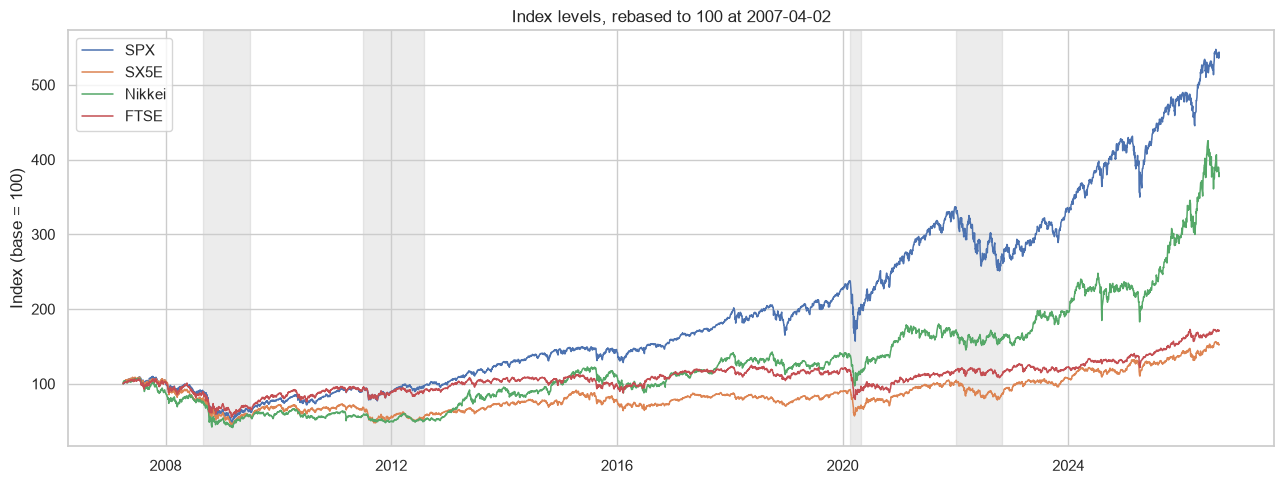

In [6]:
# Index price levels
plot_prices(prices, save_path="../outputs/index_prices.png")

**Data integrity.** All four series are continuous with no flat stretches,
vertical jumps, or gaps. The data is clean enough to model.

**Crisis synchronicity differs by episode.** In 2008 and 2020 all four
indices fall together : these were global shocks transmitted through
credit markets and a pandemic respectively. The 2011 European sovereign
debt window is different: SX5E and the Nikkei decline visibly while SPX
is roughly flat over the same period.

This asymmetry is worth flagging early. It suggests that volatility
dynamics are not simply a global factor scaled up and down by market, and
that the cross-market comparison in Stage 6 has something real to
measure.

**Long-run drift is irrelevant here.** SPX ends near 540 while SX5E ends
near 150, but GARCH models the *second* moment. The dispersion in
cumulative performance tells us nothing about which market has the more
persistent volatility, that is precisely the question estimation will
answer.

## 2.2 Return series

This is the single most informative plot in the exploratory section.

That persistence of the widening is the point. A single large move is
just an outlier. Large moves *arriving in clusters* is a statement about
the conditional variance process, and it is what GARCH is built to
capture.

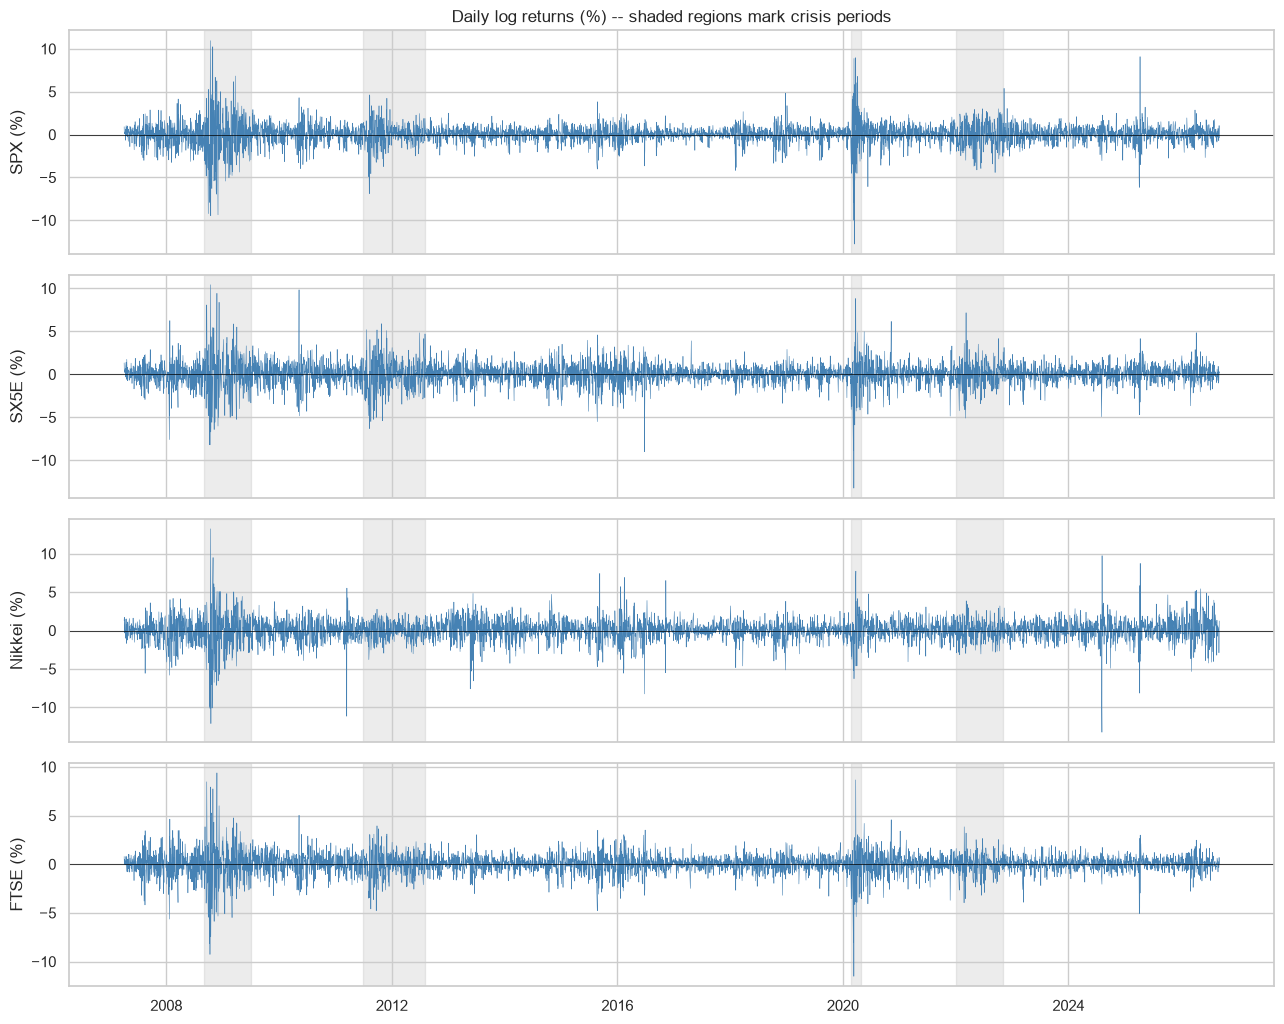

In [7]:
# Daily return series
plot_returns(returns, save_path="../outputs/returns_timeseries.png")

**Volatility clustering is unambiguous.** Every panel shows the same
structure: long stretches of thin, stable amplitude interrupted by
episodes where the band widens sharply and *remains* wide for weeks or
months. A constant-variance model cannot generate this pattern.

**The two global crises have different shapes.** The 2008 episode builds
gradually, stays elevated for roughly a year, and decays slowly. The 2020
episode is near-vertical — peak amplitude within weeks — and decays
considerably faster. These correspond to different parameter
configurations: a fast, violent onset requires a large $\alpha$ (strong
reaction to shocks), while a long tail requires a large $\beta$ (long
memory). Whether estimation reproduces this distinction is worth checking.

**2011 confirms the regional asymmetry.** SX5E and FTSE widen visibly
during the sovereign debt window; SPX reacts more mildly and the Nikkei
barely at all.

**The Nikkei has an idiosyncratic elevated regime.** Between roughly 2013
and 2016 its band is persistently wide while the other three are calm.
This coincides with Abenomics and aggressive Bank of Japan easing,
suggesting the Nikkei's high unconditional volatility (23.9%) is not
driven by crises alone but partly by domestic policy regime. The isolated
−12% spike in August 2024 — the yen carry-trade unwind — is a further
Japan-specific event with no counterpart in the other series.

### 2.3 Rolling volatility

The return plot shows clustering qualitatively; this one puts a number on
it. A 21-day rolling standard deviation, annualised by $\sqrt{252}$, gives
a readable volatility *level* at each point in time.

The window length is a trade-off. Too short and the estimate is noisy;
too long and it smooths away the regime shifts we are trying to see. 21
trading days is one calendar month, which is responsive enough to track the onset
of a crisis, stable enough to interpret.

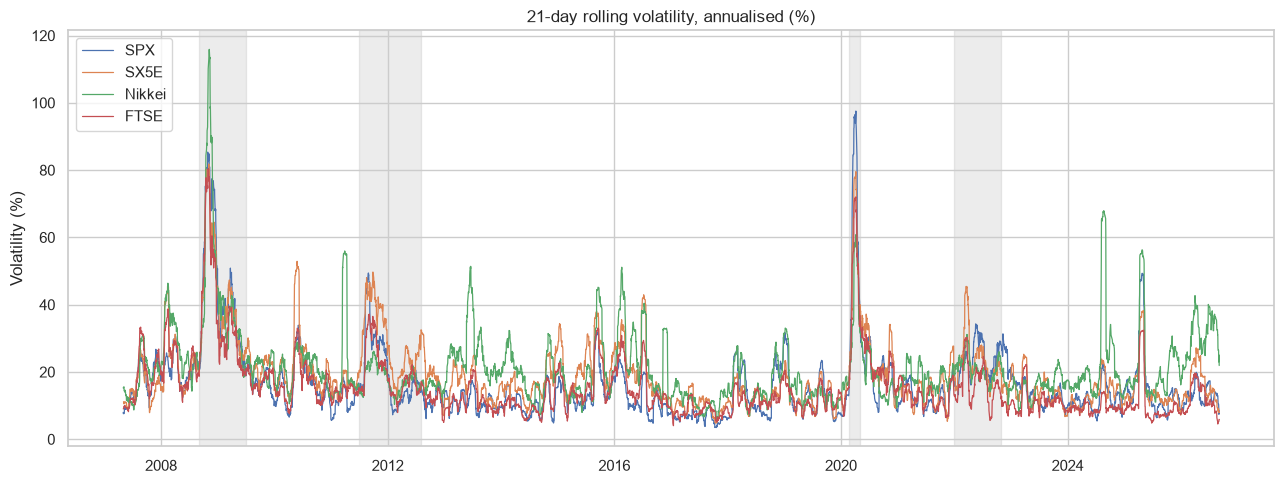

In [8]:
# Rolling volatility
plot_rolling_volatility(returns, window=21,
                        save_path="../outputs/rolling_volatility.png")

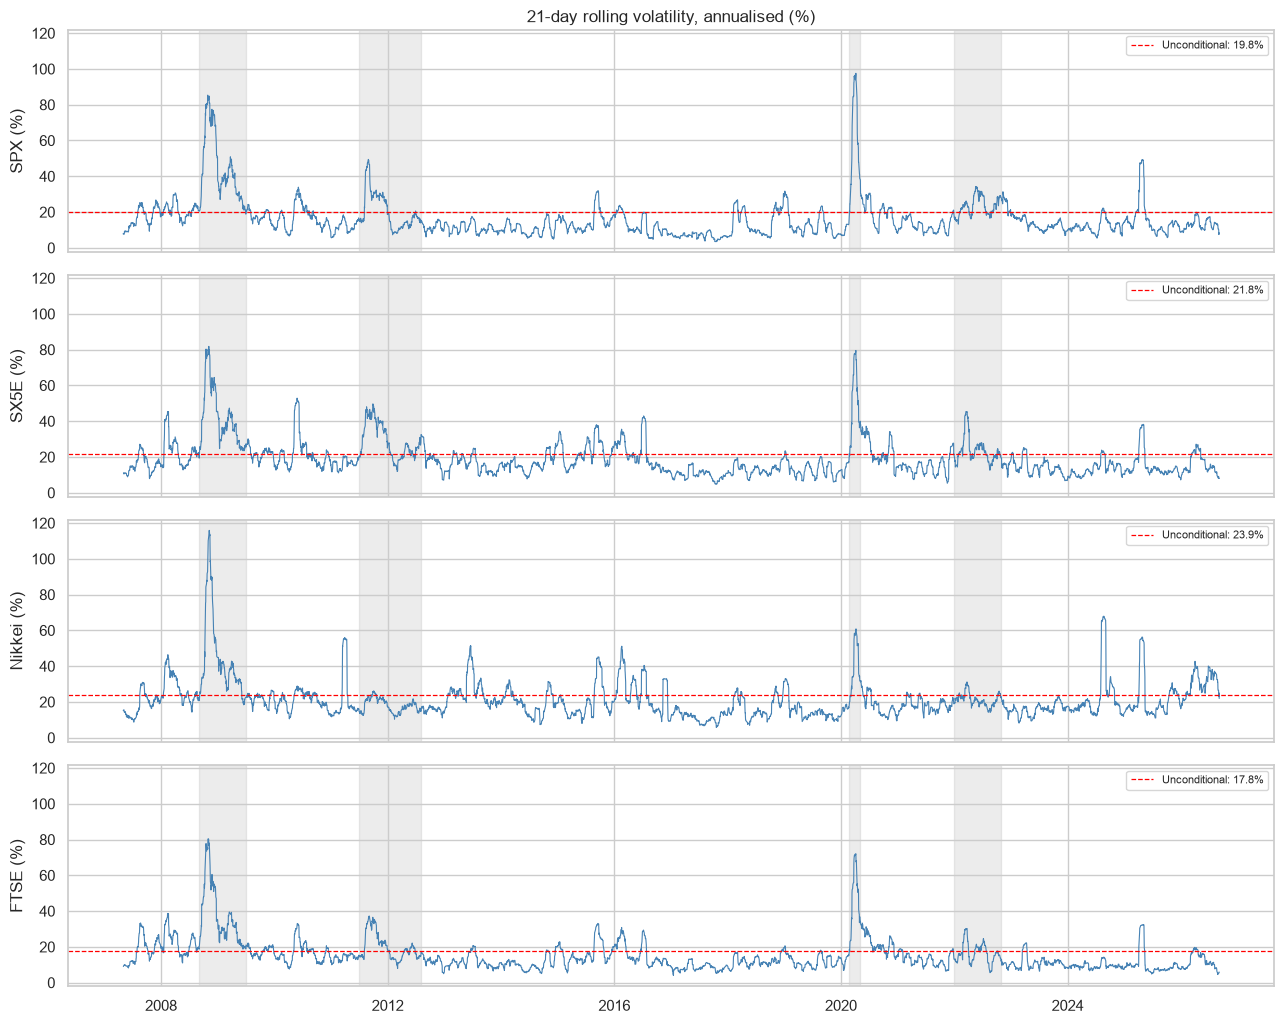

In [9]:
# Rolling volatility, separate panels
plot_rolling_volatility_panels(returns, window=21,
                               save_path="../outputs/rolling_volatility_panels.png")

**Volatility spans more than a factor of ten.** The baseline in calm
periods is 10–15% annualised; the 2008 peak reaches 115% for the Nikkei
and the 2020 peak reaches 97% for SPX. 

**The two global crises have distinct shapes.** 2008 produces a broad
plateau: volatility stays between 40% and 60% for roughly nine months
before subsiding. 2020 is a spike: a higher peak, but back near 20%
within a few months. This is the visual signature of the $\alpha$ / $\beta$
distinction.

**The Nikkei's excess volatility is not crisis-driven.** The green line
sits above the others through 2013–2016 and again from 2024 onward,
periods in which the other three indices are calm. These correspond to
Abenomics-era monetary expansion and to the 2024 exit from negative
rates, which triggered the carry-trade unwind visible as the isolated
67% spike. Japan's rank as the most volatile market therefore reflects a
domestic policy regime.

**2011 is regional.** SX5E reaches roughly 50% during the sovereign debt
window while SPX stays near 30%

## 2.4 Return distributions

The previous plots characterise volatility through time. This one
characterises the *shape* of the return distribution, which determines how
extreme the extremes can be.

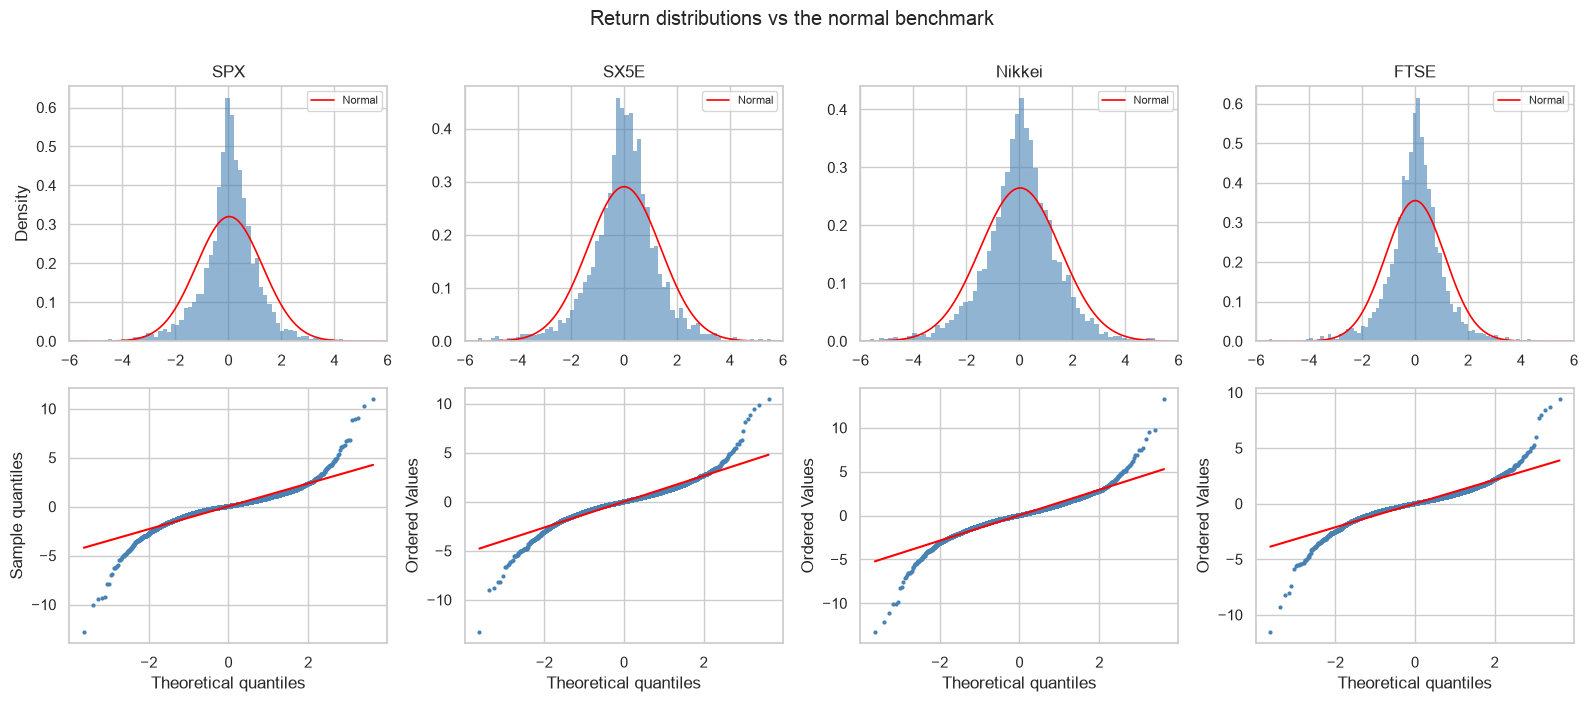

In [10]:
# Return distributions vs the normal benchmark
plot_return_distributions(returns,
                          save_path="../outputs/return_distributions.png")

**The histogram shows both sides of fat tails.** 
Fat-tailed return distributions are therefore better described in three
parts: more very quiet days than normality predicts, fewer moderate days,
and far more extreme days. 

**The QQ plots show where normality actually fails.** Between roughly
$-2$ and $+2$ theoretical quantiles, all four series lie almost exactly on
the reference line. The normal approximation is adequate for about 95% of
observations.

**The departure is asymmetric.** The left tail pulls away from the line
more sharply than the right in every panel.

**Implication for risk measurement.** A 95% VaR computed under normality
would be roughly adequate, since the 5% quantile still sits close to the
line. A 99% VaR would not. This is one reason regulatory frameworks
specify the higher confidence level, and it is precisely where the Gaussian
approximation stops working.

## 2.5 Formal specification tests
**ARCH-LM test (Engle 1982).** Regress squared demeaned returns on their
own lags. Under the null of no ARCH effects — a constant conditional
variance — every slope is zero and $T \cdot R^2 \sim \chi^2_q$. Rejection
is the formal justification for a conditional variance model.

**Ljung–Box test.** Applied separately to $r_t$ and $r_t^2$. The pattern
we expect is the following:

| Series | Expected result | Interpretation |
|---|---|---|
| $r_t$ | No significant autocorrelation | Direction is unpredictable — weak-form efficiency |
| $r_t^2$ | Strong autocorrelation | Magnitude *is* predictable — volatility clusters |

In [11]:
# ARCH-LM test
arch_results = arch_lm_test(returns, lags=(1, 5, 10, 22))
arch_results

/Users/huang/Desktop/StockMarket Projects/garch_project/.venv/lib/python3.11/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


LM stat    R^2  p-value  Reject H0 at 1%
Index  Lags                                            
SPX    1      510.9430  10.5%   0.0000             True
       5    1,292.8121  26.4%   0.0000             True
       10   1,371.1144  28.1%   0.0000             True
       22   1,465.3720  30.0%   0.0000             True
SX5E   1      123.3849   2.5%   0.0000             True
       5      705.4106  14.5%   0.0000             True
       10     779.4080  16.0%   0.0000             True
       22     828.1433  17.0%   0.0000             True
Nikkei 1      563.4473  11.9%   0.0000             True
       5      879.7533  18.5%   0.0000             True
       10     963.0198  20.3%   0.0000             True
       22     996.2814  21.0%   0.0000             True
FTSE   1      231.3907   4.7%   0.0000             True
       5      940.2372  19.2%   0.0000             True
       10   1,023.5575  20.9%   0.0000             True
       22   1,083.3748  22.1%   0.0000             True

**H0 is rejected in all sixteen tests.** Every $p$-value is
indistinguishable from zero. 

**The statistic rises monotonically with lag length.** The latter has a
one-day memory and cannot generate dependence at these horizons without
a large number of lags.

**The cross-sectional pattern is informative.** SPX has the *lowest*
unconditional volatility but the *highest* one-lag LM statistic (511
against 123 for SX5E), consistent with its being the calmest market on
average while reacting most sharply to shocks. SX5E shows the opposite profile:
a weak immediate response but the largest proportional increase from one
lag to five.


In [13]:
# Ljung-Box test on returns vs squared returns
lb_results = ljung_box_test(returns, lags=(5, 10, 22))
lb_results

Q(r)   p(r)     Q(r^2)  p(r^2)
Index  Lags                                   
SPX    5     80.4280 0.0000 2,769.8852  0.0000
       10   115.1219 0.0000 4,724.5526  0.0000
       22   172.2836 0.0000 6,824.3163  0.0000
SX5E   5     18.6895 0.0022 1,195.9355  0.0000
       10    33.7469 0.0002 1,897.6616  0.0000
       22    47.8388 0.0011 2,767.5247  0.0000
Nikkei 5     17.8269 0.0032 1,768.7890  0.0000
       10    20.3536 0.0261 2,630.9821  0.0000
       22    43.4503 0.0042 3,509.6391  0.0000
FTSE   5     27.8556 0.0000 1,770.6066  0.0000
       10    45.1980 0.0000 2,906.9152  0.0000
       22    70.5314 0.0000 4,538.0187  0.0000

**The contrast between the two columns is the result.** At twenty-two
lags, the Ljung–Box statistic on squared returns exceeds that on returns
by a factor of 40 (SPX) to 81 (Nikkei). Direction carries little
exploitable structure; magnitude carries a great deal. That asymmetry is
the entire justification for modelling the conditional variance while
leaving the conditional mean as a constant.

**Returns are not, however, serially independent.** $Q(r)$ is significant
at conventional levels for most index–lag combinations, which deserves an
explanation rather than being passed over.

Three factors contribute. 

1） **non-synchronous
trading**: an index aggregates hundreds of constituents that do not trade
simultaneously, so information propagates into the index with a lag,
inducing spurious positive autocorrelation at the index level (Lo and
MacKinlay, 1990). 

2） **sample size**: with $N \approx 4{,}900$,
inverting $Q \approx N\sum\rho_k^2$ implies an average
$|\rho_k| \approx 0.04$ for SPX. That is statistically significant and
economically meaningless — it would not survive bid-ask spreads, let
alone transaction costs. 

3） **short-horizon reversal during crises**,
where sharp declines are frequently followed by sharp rebounds.

**Consequence for specification.** Strictly, significant $Q(r)$ argues for
an AR term in the mean equation. In practice an AR(1) coefficient of 0.04
explains under 0.2% of return variance, leaving residuals almost identical
to demeaned returns. We therefore retain a constant mean throughout, and
verify in Stage 6 that adding an AR(1) term leaves the persistence
estimates materially unchanged.